# Advection-Diffusion Toy: Dimension and M Sweep

This notebook runs MESS (multiple M) and MH across dimensions, saves all chains, and plots ESS/MSJD vs dimension.

Notes:
- Chains are saved under estimations/AD_toy_<seed>_<n_iters>_dim_M_sweep.
- Each chain is stored as one .npz per (d, M, alg).
- Set run flags in the configuration cell to control execution.

## Imports

In [1]:
import os
import sys
import time
import zipfile
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(repo_root, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from multiproposal.data.advection_diffusion import generate_advection_diffusion_data
from multiproposal.problems.advection_diffusion import AdvectionDiffusionToy
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.mh import mh_chain
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size

## Configuration

In [2]:
# Sweep configuration
seed_data = 0
seed_mcmc = 0
n_iters = 500000
burn_in = 1000
thin = 1
max_lag = 1500

d_list = [10, 20, 30, 40]
M_list = [1, 20, 100, 200]

# Data hyperparameters
kappa = 0.02
sigma = 0.5
alpha = 3
gamma = 2
tau2 = 2.0
a_mode = 'nearest_neighbor'
use_prior_A = True

# Observation configuration
obs_highest_freq = 6
obs_bandwidth = 3
obs_config = "central_modes"

# MH proposal stds per d (tuned to get 23.4% for d=20).
mh_proposal_stds_scaled = np.repeat(0.000018, len(d_list))
if len(mh_proposal_stds_scaled) != len(d_list):
    raise ValueError('mh_proposal_stds_scaled must match d_list length')

# Run flags (default False to avoid long runs).
run_mess = True
run_mh = True
recompute_corrupt_chains = True

# Parallelization (dim-level)
use_parallel = True
max_workers = 1  # Keep small to avoid overloading the machine.

# Cache generated datasets per dimension.
datasets_by_dim = {}

# Output directory under estimations/
output_dir = Path(repo_root) / 'estimations' / "AD_toy_dim_M_sweep" / (
    f"priorA{use_prior_A}_obs_{obs_config}_tau2{tau2}_sigma{sigma}_seed{seed_data}_Niters{n_iters}"
 )
output_dir.mkdir(parents=True, exist_ok=True)

print('Output dir:', output_dir)

Output dir: /Users/guillers/Documents/GitHub/multiproposal/estimations/AD_toy_dim_M_sweep/priorATrue_obs_central_modes_tau22.0_sigma0.5_seed0_Niters500000


## Helpers

In [3]:
def compute_msjd_per_param(chain):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    jumps = np.diff(chain, axis=0)
    msjd = np.mean(jumps * jumps, axis=0)
    return msjd

def compute_ess_per_param(chain, max_lag):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    variances = np.var(chain, axis=0)
    if np.all(variances == 0):
        return np.zeros(chain.shape[1])
    ess_vals = estimate_effective_sample_size(chain, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    ess_vals[variances == 0] = 0.0
    return ess_vals

def chain_path(output_dir, d, alg, M=None, proposal_std=None):
    alg_key = alg.lower()
    if alg_key == 'mh':
        if proposal_std is None:
            return output_dir / f'chain_d{d}_mh_sigma2unknown.npz'
        sigma_tag = f'{proposal_std:.6g}'
        return output_dir / f'chain_d{d}_mh_sigma2{sigma_tag}.npz'
    return output_dir / f'chain_d{d}_{alg_key}_M{M}.npz'

def load_chain(output_dir, d, alg, M=None, proposal_std=None):
    path = chain_path(output_dir, d, alg, M, proposal_std=proposal_std)
    if not path.exists() and alg.lower() == 'mh' and proposal_std is None:
        matches = sorted(output_dir.glob(f'chain_d{d}_mh_sigma2*.npz'))
        if matches:
            path = matches[0]
    if not path.exists():
        return None
    try:
        data = np.load(path)
        return data['chain']
    except (zipfile.BadZipFile, ValueError, KeyError) as exc:
        print(f'Corrupt or unreadable chain file: {path.name} ({exc})')
        return None

def is_chain_readable(path):
    if not path.exists():
        return False
    try:
        with np.load(path) as data:
            _ = data['chain']
        return True
    except (zipfile.BadZipFile, ValueError, KeyError):
        return False

def save_chain(path, chain, metadata):
    np.savez_compressed(path, chain=chain, **metadata)

def get_obs_indices(dim_value, highest_freq, bandwidth):
    highest_freq = min(highest_freq, dim_value - 1)
    bandwidth = min(bandwidth, dim_value)
    start = max(0, highest_freq - bandwidth + 1)
    return np.arange(start, highest_freq + 1, dtype=int)

def get_dataset_for_dim(d, seed=0):
    if d in datasets_by_dim:
        return datasets_by_dim[d]
    obs_indices = get_obs_indices(d, obs_highest_freq, obs_bandwidth)
    a_mode_local = "prior" if use_prior_A else a_mode
    data = generate_advection_diffusion_data(
        dim=d,
        kappa=kappa,
        sigma=sigma,
        obs_indices=obs_indices,
        alpha=alpha,
        gamma=gamma,
        tau2=tau2,
        a_mode=a_mode_local,
        seed=seed,
    )
    data['obs_indices'] = obs_indices
    datasets_by_dim[d] = data
    return data

def build_problem_for_dim(d, seed=0):
    data = get_dataset_for_dim(d, seed=seed)
    obs_indices = data['obs_indices']
    problem = AdvectionDiffusionToy(
        dim=d,
        kappa=kappa,
        sigma=sigma,
        y=data['y'],
        obs_indices=obs_indices,
        g=data['g'],
        prior_diag=data['prior_diag'],
    )
    return problem, data['a_init'], obs_indices, data

## Tune MH

In [4]:
# # --- MH tuning (d=10) ---
# n_iters = 50000
# run_mh_tuning = True
# tune_d = 20
# mh_tune_proposal_stds = [0.0045]

# if run_mh_tuning:
#     problem_cur, x0_cur, obs_indices_cur, data_cur = build_problem_for_dim(tune_d, seed=seed_data)
#     print(f'Tuning MH at d={tune_d} with obs_indices={obs_indices_cur.tolist()}')
#     for proposal_std in mh_tune_proposal_stds:
#         out_path = chain_path(output_dir, tune_d, 'mh', proposal_std=proposal_std)
#         if out_path.exists() and is_chain_readable(out_path):
#             print(f'Skip existing: {out_path.name}')
#             continue
#         rng = np.random.default_rng(seed_mcmc)
#         t0 = time.perf_counter()
#         chain_mh, acc = mh_chain(x0_cur, problem_cur, rng, n_iters, proposal_std=proposal_std)
#         t1 = time.perf_counter()
#         post = chain_mh[::thin]
#         metadata = {
#             'alg': 'mh',
#             'd': tune_d,
#             'n_iters': n_iters,
#             'burn_in': burn_in,
#             'thin': thin,
#             'seed_mcmc': seed_mcmc,
#             'seed_data': seed_data,
#             'proposal_std': proposal_std,
#             'acceptance': acc,
#             'runtime_sec': t1 - t0,
#             'tuning': True,
#         }
#         save_chain(out_path, post, metadata)
#         print(f'Saved {out_path.name} | acc={acc:.3f} | runtime={t1 - t0:.2f}s')
# else:
#     print('MH tuning disabled.')

In [5]:
# rng = np.random.default_rng(seed_mcmc)
# chain_mh, acc = mh_chain(x0_cur, problem_cur, rng, n_iters, proposal_std=0.000018)
# acc

## Run Sweep and Save Chains

In [6]:
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
from itertools import repeat

def _run_dim_task(d_idx, d_cur, config):
    seed_mcmc = config['seed_mcmc']
    seed_data = config['seed_data']
    n_iters_dim = config['n_iters_dim']
    burn_in_cur = config['burn_in']
    thin = config['thin']
    M_list = config['M_list']
    run_mess = config['run_mess']
    run_mh = config['run_mh']
    output_dir = Path(config['output_dir'])
    mh_proposal_stds_scaled = config['mh_proposal_stds_scaled']
    recompute_corrupt_chains = config['recompute_corrupt_chains']

    problem_cur, x0_cur, obs_indices_cur, _ = build_problem_for_dim(d_cur, seed=seed_data)
    print(f'--- d={d_cur} | burn_in={burn_in_cur} | obs_indices={obs_indices_cur.tolist()}')

    # MESS sweep
    if run_mess:
        for M in M_list:
            out_path = chain_path(output_dir, d_cur, 'mess', M=M)
            if out_path.exists() and is_chain_readable(out_path):
                print(f'Skip existing: {out_path.name}')
                continue
            if out_path.exists() and not is_chain_readable(out_path):
                if recompute_corrupt_chains:
                    print(f'Recomputing corrupt chain: {out_path.name}')
                else:
                    print(f'Corrupt chain found, skipping: {out_path.name}')
                    continue
            print(f'\nStart MESS chain: d={d_cur}, M={M}, n_iters={n_iters_dim}, burn_in={burn_in_cur}, thin={thin}')
            rng = np.random.default_rng(seed_mcmc)
            chain = np.zeros((n_iters_dim + 1, x0_cur.shape[0]))
            chain[0] = x0_cur.copy()
            x = x0_cur.copy()
            t0 = time.perf_counter()
            for t in range(n_iters_dim):
                x, _, _ = mess_step(x, problem_cur, rng, M=M, use_lp=False)
                chain[t + 1] = x
            t1 = time.perf_counter()
            post = chain[::thin]
            metadata = {
                'alg': 'mess',
                'M': M,
                'd': d_cur,
                'n_iters': n_iters_dim,
                'burn_in': burn_in_cur,
                'thin': thin,
                'seed_mcmc': seed_mcmc,
                'seed_data': seed_data,
                'runtime_sec': t1 - t0,
            }
            save_chain(out_path, post, metadata)
            print(f'Saved {out_path.name}')

    # MH sweep
    if run_mh:
        mh_std = mh_proposal_stds_scaled[d_idx]
        out_path = chain_path(output_dir, d_cur, 'mh', proposal_std=mh_std)
        if out_path.exists() and is_chain_readable(out_path):
            print(f'Skip existing: {out_path.name}')
        else:
            if out_path.exists() and not is_chain_readable(out_path):
                if recompute_corrupt_chains:
                    print(f'Recomputing corrupt chain: {out_path.name}')
                else:
                    print(f'Corrupt chain found, skipping: {out_path.name}')
                    return
            print(f'\nStart MH chain: d={d_cur}, n_iters={n_iters_dim}, burn_in={burn_in_cur}, thin={thin}, proposal_std={mh_std}')
            rng = np.random.default_rng(seed_mcmc)
            t0 = time.perf_counter()
            chain_mh, acc = mh_chain(x0_cur, problem_cur, rng, n_iters_dim, proposal_std=mh_std)
            t1 = time.perf_counter()
            post = chain_mh[::thin]
            metadata = {
                'alg': 'mh',
                'd': d_cur,
                'n_iters': n_iters_dim,
                'burn_in': burn_in_cur,
                'thin': thin,
                'seed_mcmc': seed_mcmc,
                'seed_data': seed_data,
                'proposal_std': mh_std,
                'acceptance': acc,
                'runtime_sec': t1 - t0,
            }
            save_chain(out_path, post, metadata)
            print(f'Saved {out_path.name}')

if not run_mess and not run_mh:
    print('Set run_mess and/or run_mh to True to generate chains.')
else:
    # High-level run context.
    print('Starting sweep with config:')
    print({
        'seed_mcmc': seed_mcmc,
        'seed_data': seed_data,
        'n_iters_dim': n_iters,
        'burn_in': burn_in,
        'thin': thin,
        'max_lag': max_lag,
        'd_list': d_list,
        'M_list': M_list,
        'output_dir': str(output_dir),
        'run_mess': run_mess,
        'run_mh': run_mh,
        'use_parallel': use_parallel,
        'max_workers': max_workers,
        'recompute_corrupt_chains': recompute_corrupt_chains,
    })

    config = {
        'seed_mcmc': seed_mcmc,
        'seed_data': seed_data,
        'n_iters_dim': n_iters,
        'burn_in': burn_in,
        'thin': thin,
        'M_list': M_list,
        'run_mess': run_mess,
        'run_mh': run_mh,
        'output_dir': str(output_dir),
        'mh_proposal_stds_scaled': mh_proposal_stds_scaled,
        'recompute_corrupt_chains': recompute_corrupt_chains,
    }

    tasks = list(enumerate(d_list))
    if use_parallel and max_workers > 1:
        print(f'Parallel sweep by dimension with max_workers={max_workers}')
        try:
            mp_context = mp.get_context('fork')
        except ValueError:
            mp_context = None
        if mp_context is None:
            print('Fork context unavailable; falling back to serial execution.')
            for d_idx, d_cur in tasks:
                _run_dim_task(d_idx, d_cur, config)
        else:
            with ProcessPoolExecutor(max_workers=max_workers, mp_context=mp_context) as executor:
                list(executor.map(_run_dim_task, [t[0] for t in tasks], [t[1] for t in tasks], repeat(config)))
    else:
        print('Serial sweep by dimension')
        for d_idx, d_cur in tasks:
            _run_dim_task(d_idx, d_cur, config)

print(f"Sweep completed. Chains saved to: {output_dir}")

Starting sweep with config:
{'seed_mcmc': 0, 'seed_data': 0, 'n_iters_dim': 500000, 'burn_in': 1000, 'thin': 1, 'max_lag': 1500, 'd_list': [10, 20, 30, 40], 'M_list': [1, 20, 100, 200], 'output_dir': '/Users/guillers/Documents/GitHub/multiproposal/estimations/AD_toy_dim_M_sweep/priorATrue_obs_central_modes_tau22.0_sigma0.5_seed0_Niters500000', 'run_mess': True, 'run_mh': True, 'use_parallel': True, 'max_workers': 1, 'recompute_corrupt_chains': True}
Serial sweep by dimension
--- d=10 | burn_in=1000 | obs_indices=[4, 5, 6]
Skip existing: chain_d10_mess_M1.npz
Skip existing: chain_d10_mess_M20.npz
Skip existing: chain_d10_mess_M100.npz
Skip existing: chain_d10_mess_M200.npz
Skip existing: chain_d10_mh_sigma21.8e-05.npz
--- d=20 | burn_in=1000 | obs_indices=[4, 5, 6]
Skip existing: chain_d20_mess_M1.npz
Skip existing: chain_d20_mess_M20.npz
Skip existing: chain_d20_mess_M100.npz
Skip existing: chain_d20_mess_M200.npz
Skip existing: chain_d20_mh_sigma21.8e-05.npz
--- d=30 | burn_in=1000 | 

Checking saved chains:
-- d=10
  MESS d=10 M=1
  shape: (500001, 45)
  MESS d=10 M=20
  shape: (500001, 45)
  MESS d=10 M=100
  shape: (500001, 45)
  MESS d=10 M=200
  shape: (500001, 45)
  MH d=10 sigma2=1.8e-05
  shape: (500001, 45)


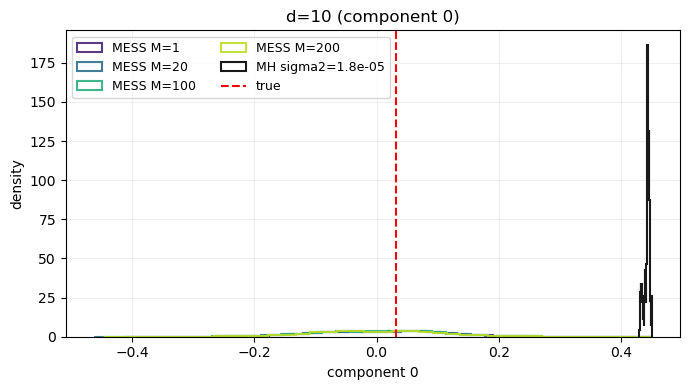

  MESS d=10 M=1
  shape: (500001, 45)
  MESS d=10 M=20
  shape: (500001, 45)
  MESS d=10 M=100
  shape: (500001, 45)
  MESS d=10 M=200
  shape: (500001, 45)
  MH d=10 sigma2=1.8e-05
  shape: (500001, 45)


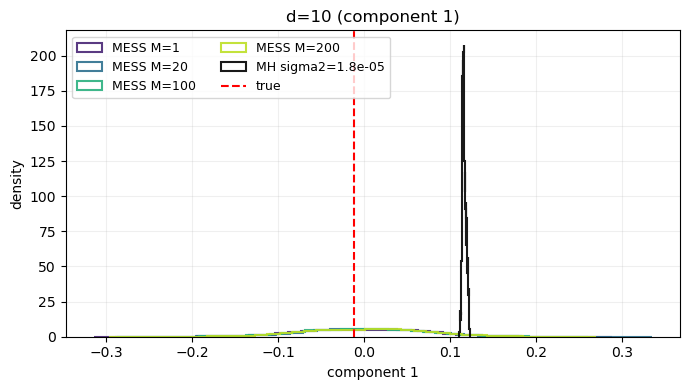

-- d=20
  MESS d=20 M=1
  shape: (500001, 190)
  MESS d=20 M=20
  shape: (500001, 190)
  MESS d=20 M=100
  shape: (500001, 190)
  MESS d=20 M=200
  shape: (500001, 190)
  MH d=20 sigma2=1.8e-05
  shape: (500001, 190)


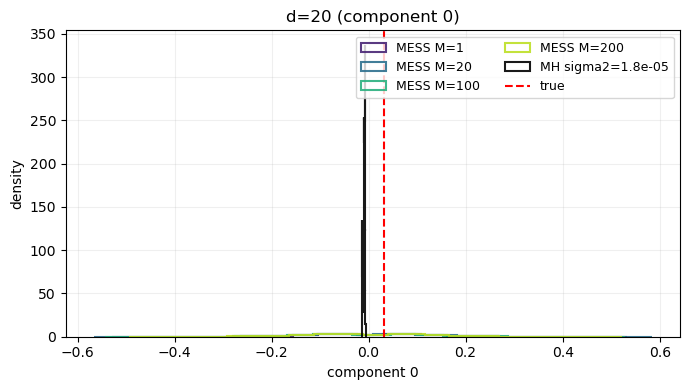

  MESS d=20 M=1
  shape: (500001, 190)
  MESS d=20 M=20
  shape: (500001, 190)
  MESS d=20 M=100
  shape: (500001, 190)
  MESS d=20 M=200
  shape: (500001, 190)
  MH d=20 sigma2=1.8e-05
  shape: (500001, 190)


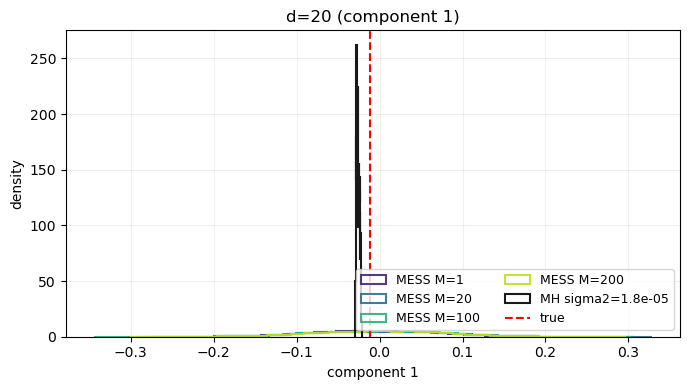

-- d=30
  MESS d=30 M=1
  shape: (500001, 435)
  MESS d=30 M=20
  shape: (500001, 435)
  MESS d=30 M=100
  shape: (500001, 435)
  MESS d=30 M=200
  shape: (500001, 435)
  MH d=30 sigma2=1.8e-05
  shape: (500001, 435)


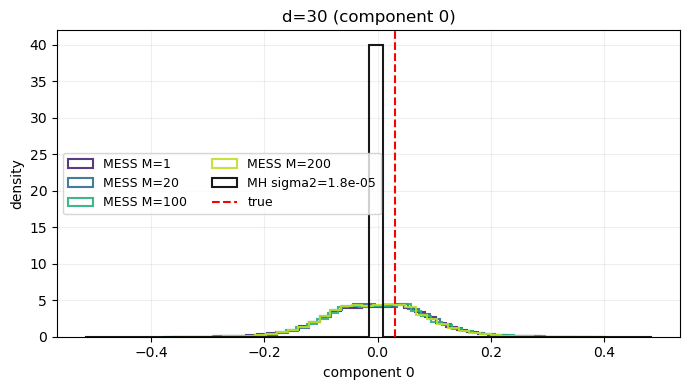

  MESS d=30 M=1
  shape: (500001, 435)
  MESS d=30 M=20
  shape: (500001, 435)
  MESS d=30 M=100
  shape: (500001, 435)
  MESS d=30 M=200
  shape: (500001, 435)
  MH d=30 sigma2=1.8e-05
  shape: (500001, 435)


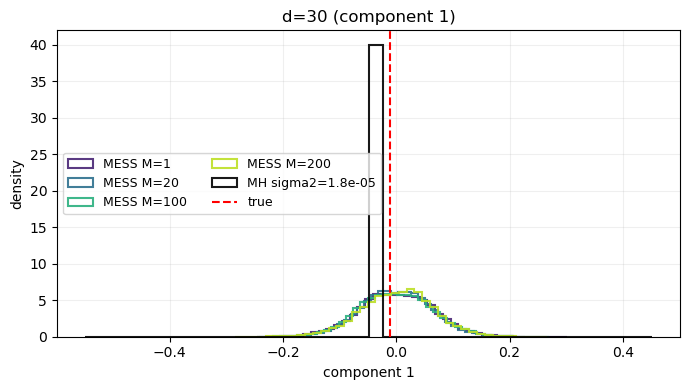

-- d=40
  MESS d=40 M=1
  shape: (500001, 780)
  MESS d=40 M=20
  shape: (500001, 780)
  MESS d=40 M=100
  shape: (500001, 780)
  MESS d=40 M=200
  shape: (500001, 780)
  MH d=40 sigma2=1.8e-05
  shape: (500001, 780)


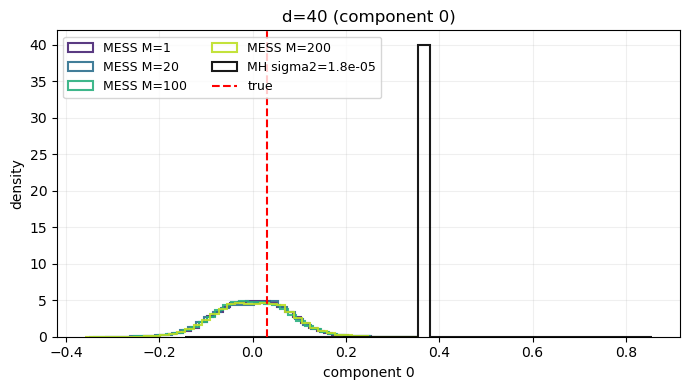

  MESS d=40 M=1
  shape: (500001, 780)
  MESS d=40 M=20
  shape: (500001, 780)
  MESS d=40 M=100
  shape: (500001, 780)
  MESS d=40 M=200
  shape: (500001, 780)
  MH d=40 sigma2=1.8e-05
  shape: (500001, 780)


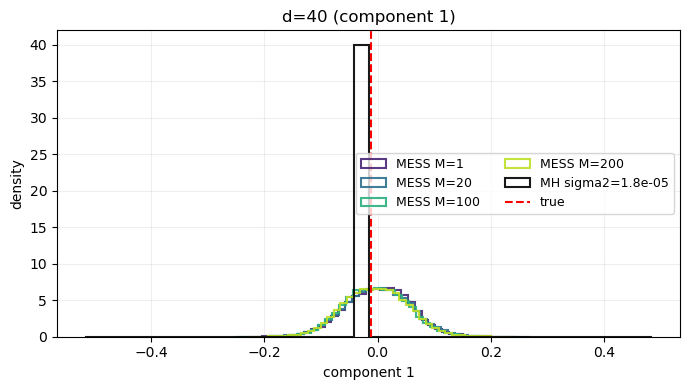

In [8]:
# Quick check: print chain shapes and histogram for component 0 and 1.
component_indices = [0, 1]
hist_thin = 10
hist_bins = 40

def _collect_chain_values(chain, component_idx):
    if chain is None or chain.size == 0:
        return None
    print(f'  shape: {chain.shape}')
    return chain[::hist_thin, component_idx]

def _plot_hist_for_dim(d_cur, series, component_idx):
    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    for label, values, color in series:
        if values is None or values.size == 0:
            continue
        ax.hist(
            values,
            bins=hist_bins,
            density=True,
            alpha=0.9,
            histtype='step',
            linewidth=1.5,
            color=color,
            label=label,
        )
    data = get_dataset_for_dim(d_cur, seed=seed_data)
    true_val = float(data['a_true'][component_idx])
    ax.axvline(true_val, color='red', linestyle='--', linewidth=1.5, label='true')
    ax.set_title(f'd={d_cur} (component {component_idx})')
    ax.set_xlabel(f'component {component_idx}')
    ax.set_ylabel('density')
    ax.grid(alpha=0.2)
    ax.legend(loc='best', ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

print('Checking saved chains:')
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(M_list)))
for d_idx, d_cur in enumerate(d_list):
    print(f'-- d={d_cur}')
    for component_idx in component_indices:
        series = []
        for M, color in zip(M_list, colors):
            chain = load_chain(output_dir, d_cur, 'mess', M=M)
            if chain is None or chain.size == 0:
                print(f'  Missing MESS d={d_cur} M={M}')
                values = None
            else:
                print(f'  MESS d={d_cur} M={M}')
                values = _collect_chain_values(chain, component_idx)
            series.append((f'MESS M={M}', values, color))
        mh_std = mh_proposal_stds_scaled[d_idx]
        chain_mh = load_chain(output_dir, d_cur, 'mh', proposal_std=mh_std)
        if chain_mh is None or chain_mh.size == 0:
            print(f'  Missing MH d={d_cur} sigma2={mh_std}')
            mh_values = None
        else:
            print(f'  MH d={d_cur} sigma2={mh_std}')
            mh_values = _collect_chain_values(chain_mh, component_idx)
        series.append((f'MH sigma2={mh_std}', mh_values, 'black'))
        _plot_hist_for_dim(d_cur, series, component_idx)

## Load Chains and Compute ESS/MSJD

In [9]:
def compute_metrics_by_dim(
    burnin=0,
    max_lag=1500,
    components=None,
    metrics_path=None,
    force_recompute=False,
    save_every_update=True,
 ):
    def _unwrap_loaded(value):
        if isinstance(value, np.ndarray) and value.dtype == object and value.size == 1:
            return value.item()
        if isinstance(value, np.ndarray):
            return value.tolist()
        return value

    def _ensure_list(values, length, fill_value=np.nan):
        values = list(values) if values is not None else []
        if len(values) < length:
            values = values + [fill_value] * (length - len(values))
        if len(values) > length:
            values = values[:length]
        return values

    def _ensure_by_M(metrics_dict, fill_value=np.nan):
        metrics_dict = metrics_dict or {}
        for M in M_list:
            metrics_dict[M] = _ensure_list(metrics_dict.get(M, []), len(d_list), fill_value=fill_value)
        return metrics_dict

    def _ensure_by_M_components(metrics_dict, components_count):
        metrics_dict = metrics_dict or {}
        fill_value = [np.nan] * components_count
        for M in M_list:
            metrics_dict[M] = _ensure_list(
                metrics_dict.get(M, []),
                len(d_list),
                fill_value=fill_value,
            )
        return metrics_dict

    def _is_missing(val):
        if val is None:
            return True
        try:
            return bool(np.isnan(val))
        except TypeError:
            return False

    def _apply_burnin(chain):
        if chain is None:
            return None
        if burnin is None or burnin <= 0:
            return chain
        if chain.shape[0] <= burnin:
            return chain[:0]
        return chain[burnin:]

    def _normalize_components(components_in, dim):
        if components_in is None:
            return list(range(dim))
        return [int(c) for c in components_in]

    def _split_components(components_idx, dim):
        valid_indices = []
        valid_positions = []
        for pos, idx in enumerate(components_idx):
            if 0 <= idx < dim:
                valid_indices.append(idx)
                valid_positions.append(pos)
        return valid_indices, valid_positions

    def _compute_from_chain(chain, components_idx):
        components_count = len(components_idx)
        selected_ess = [np.nan] * components_count
        selected_msjd = [np.nan] * components_count
        if chain is None or chain.size == 0:
            return selected_ess, selected_msjd
        dim = chain.shape[1]
        valid_indices, valid_positions = _split_components(components_idx, dim)
        if not valid_indices:
            return selected_ess, selected_msjd
        chain_sel = chain[:, valid_indices]
        ess_vals = compute_ess_per_param(chain_sel, max_lag=max_lag)
        msjd_vals = compute_msjd_per_param(chain_sel)
        for pos, val in zip(valid_positions, ess_vals):
            selected_ess[pos] = float(val)
        for pos, val in zip(valid_positions, msjd_vals):
            selected_msjd[pos] = float(val)
        return selected_ess, selected_msjd

    def _mean_selected(selected):
        arr = np.array(selected, dtype=float)
        if arr.size == 0:
            return np.nan
        if np.all(np.isnan(arr)):
            return np.nan
        return float(np.nanmean(arr))

    def _save_metrics(metrics_dict):
        if metrics_path is None:
            return
        metrics_to_save = dict(metrics_dict)
        metrics_to_save['components'] = np.array(components_list, dtype=int)
        metrics_to_save.pop('d_list', None)
        metrics_to_save.pop('M_list', None)
        np.savez_compressed(
            metrics_path,
            **metrics_to_save,
            d_list=np.array(d_list),
            M_list=np.array(M_list),
        )
        print(f'Saved metrics to {metrics_path}')

    metrics = None
    did_update = False
    components_list = None
    if metrics_path is not None and metrics_path.exists() and not force_recompute:
        print(f'Using cached metrics at {metrics_path}')
        cached = dict(np.load(metrics_path, allow_pickle=True))
        metrics = {k: _unwrap_loaded(v) for k, v in cached.items()}
        if components is not None and 'components' in metrics:
            cached_components = [int(v) for v in list(metrics['components'])]
            if list(components) != cached_components:
                print('Cached metrics components do not match; recomputing.')
                metrics = None

    if metrics is None:
        # Initialize metrics from scratch.
        components_list = _normalize_components(components, dim=max(d_list))
        components_count = len(components_list)
        metrics = {
            'components': components_list,
            'ess_by_M': {M: [] for M in M_list},
            'msjd_by_M': {M: [] for M in M_list},
            'ess_by_M_components': {M: [] for M in M_list},
            'msjd_by_M_components': {M: [] for M in M_list},
            'ess_mh': [],
            'msjd_mh': [],
            'ess_mh_components': [],
            'msjd_mh_components': [],
        }
        for d_idx, d_cur in enumerate(d_list):
            for M in M_list:
                chain = load_chain(output_dir, d_cur, 'mess', M=M)
                chain = _apply_burnin(chain)
                if chain is None:
                    metrics['ess_by_M'][M].append(np.nan)
                    metrics['msjd_by_M'][M].append(np.nan)
                    metrics['ess_by_M_components'][M].append([np.nan] * components_count)
                    metrics['msjd_by_M_components'][M].append([np.nan] * components_count)
                    continue
                selected_ess, selected_msjd = _compute_from_chain(chain, components_list)
                metrics['ess_by_M'][M].append(_mean_selected(selected_ess))
                metrics['msjd_by_M'][M].append(_mean_selected(selected_msjd))
                metrics['ess_by_M_components'][M].append(selected_ess)
                metrics['msjd_by_M_components'][M].append(selected_msjd)
                did_update = True
                if save_every_update:
                    _save_metrics(metrics)

            mh_std = mh_proposal_stds_scaled[d_idx]
            chain_mh = load_chain(output_dir, d_cur, 'mh', proposal_std=mh_std)
            chain_mh = _apply_burnin(chain_mh)
            if chain_mh is None:
                metrics['ess_mh'].append(np.nan)
                metrics['msjd_mh'].append(np.nan)
                metrics['ess_mh_components'].append([np.nan] * components_count)
                metrics['msjd_mh_components'].append([np.nan] * components_count)
            else:
                selected_ess, selected_msjd = _compute_from_chain(chain_mh, components_list)
                metrics['ess_mh'].append(_mean_selected(selected_ess))
                metrics['msjd_mh'].append(_mean_selected(selected_msjd))
                metrics['ess_mh_components'].append(selected_ess)
                metrics['msjd_mh_components'].append(selected_msjd)
                did_update = True
                if save_every_update:
                    _save_metrics(metrics)

        return metrics, did_update

    components_list = [int(v) for v in list(metrics.get('components', []))]
    if not components_list:
        components_list = _normalize_components(components, dim=max(d_list))
        metrics['components'] = components_list
    components_count = len(components_list)

    metrics['ess_by_M'] = _ensure_by_M(metrics.get('ess_by_M'))
    metrics['msjd_by_M'] = _ensure_by_M(metrics.get('msjd_by_M'))
    metrics['ess_by_M_components'] = _ensure_by_M_components(
        metrics.get('ess_by_M_components'),
        components_count,
    )
    metrics['msjd_by_M_components'] = _ensure_by_M_components(
        metrics.get('msjd_by_M_components'),
        components_count,
    )
    metrics['ess_mh'] = _ensure_list(metrics.get('ess_mh', []), len(d_list))
    metrics['msjd_mh'] = _ensure_list(metrics.get('msjd_mh', []), len(d_list))
    metrics['ess_mh_components'] = _ensure_list(
        metrics.get('ess_mh_components', []),
        len(d_list),
        fill_value=[np.nan] * components_count,
    )
    metrics['msjd_mh_components'] = _ensure_list(
        metrics.get('msjd_mh_components', []),
        len(d_list),
        fill_value=[np.nan] * components_count,
    )

    for d_idx, d_cur in enumerate(d_list):
        for M in M_list:
            if any([
                _is_missing(metrics['ess_by_M'][M][d_idx]),
                _is_missing(metrics['msjd_by_M'][M][d_idx]),
            ]):
                chain = load_chain(output_dir, d_cur, 'mess', M=M)
                chain = _apply_burnin(chain)
                if chain is None:
                    continue
                selected_ess, selected_msjd = _compute_from_chain(chain, components_list)
                metrics['ess_by_M'][M][d_idx] = _mean_selected(selected_ess)
                metrics['msjd_by_M'][M][d_idx] = _mean_selected(selected_msjd)
                metrics['ess_by_M_components'][M][d_idx] = selected_ess
                metrics['msjd_by_M_components'][M][d_idx] = selected_msjd
                did_update = True
                if save_every_update:
                    _save_metrics(metrics)

        if any([
            _is_missing(metrics['ess_mh'][d_idx]),
            _is_missing(metrics['msjd_mh'][d_idx]),
        ]):
            mh_std = mh_proposal_stds_scaled[d_idx]
            chain_mh = load_chain(output_dir, d_cur, 'mh', proposal_std=mh_std)
            chain_mh = _apply_burnin(chain_mh)
            if chain_mh is None:
                continue
            selected_ess, selected_msjd = _compute_from_chain(chain_mh, components_list)
            metrics['ess_mh'][d_idx] = _mean_selected(selected_ess)
            metrics['msjd_mh'][d_idx] = _mean_selected(selected_msjd)
            metrics['ess_mh_components'][d_idx] = selected_ess
            metrics['msjd_mh_components'][d_idx] = selected_msjd
            did_update = True
            if save_every_update:
                _save_metrics(metrics)

    return metrics, did_update

recompute_metrics = False
metrics_path = output_dir / 'effss_msjd.npz'
components = [0, 1, 2, 3, 9, 10, 16, 17]  # Indices into a_true to summarize.
metrics, metrics_updated = compute_metrics_by_dim(
    burnin=10000,
    max_lag=1500,
    components=components,
    metrics_path=metrics_path,
    force_recompute=recompute_metrics,
 )
if metrics_path.exists() and not recompute_metrics and not metrics_updated:
    print(f'Metrics file already exists, not overwriting: {metrics_path}')
else:
    metrics_to_save = dict(metrics)
    metrics_to_save['components'] = np.array(metrics.get('components', components), dtype=int)
    metrics_to_save.pop('d_list', None)
    metrics_to_save.pop('M_list', None)
    np.savez_compressed(
        metrics_path,
        **metrics_to_save,
        d_list=np.array(d_list),
        M_list=np.array(M_list),
    )
    print(f'Saved metrics to {metrics_path}')
metrics.keys()

Using cached metrics at /Users/guillers/Documents/GitHub/multiproposal/estimations/AD_toy_dim_M_sweep/priorATrue_obs_central_modes_tau22.0_sigma0.5_seed0_Niters500000/effss_msjd.npz
Estimating ESS for each parameter.
Saved metrics to /Users/guillers/Documents/GitHub/multiproposal/estimations/AD_toy_dim_M_sweep/priorATrue_obs_central_modes_tau22.0_sigma0.5_seed0_Niters500000/effss_msjd.npz
Estimating ESS for each parameter.
Saved metrics to /Users/guillers/Documents/GitHub/multiproposal/estimations/AD_toy_dim_M_sweep/priorATrue_obs_central_modes_tau22.0_sigma0.5_seed0_Niters500000/effss_msjd.npz
Estimating ESS for each parameter.
Saved metrics to /Users/guillers/Documents/GitHub/multiproposal/estimations/AD_toy_dim_M_sweep/priorATrue_obs_central_modes_tau22.0_sigma0.5_seed0_Niters500000/effss_msjd.npz
Estimating ESS for each parameter.
Saved metrics to /Users/guillers/Documents/GitHub/multiproposal/estimations/AD_toy_dim_M_sweep/priorATrue_obs_central_modes_tau22.0_sigma0.5_seed0_Niters

dict_keys(['components', 'ess_by_M', 'msjd_by_M', 'ess_by_M_components', 'msjd_by_M_components', 'ess_mh', 'msjd_mh', 'ess_mh_components', 'msjd_mh_components', 'd_list', 'M_list'])

## Plot ESS/MSJD vs Dimension

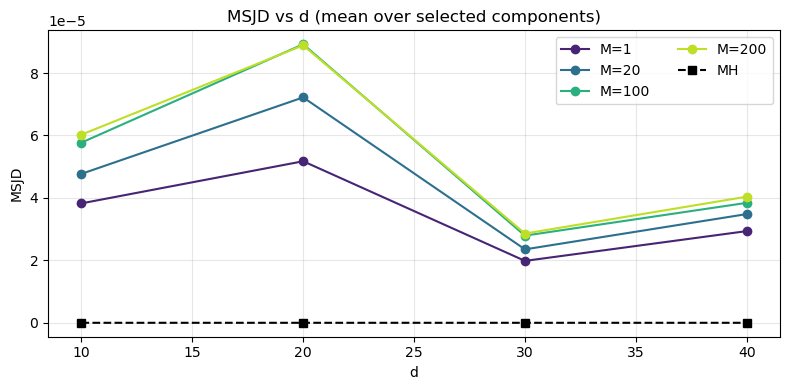

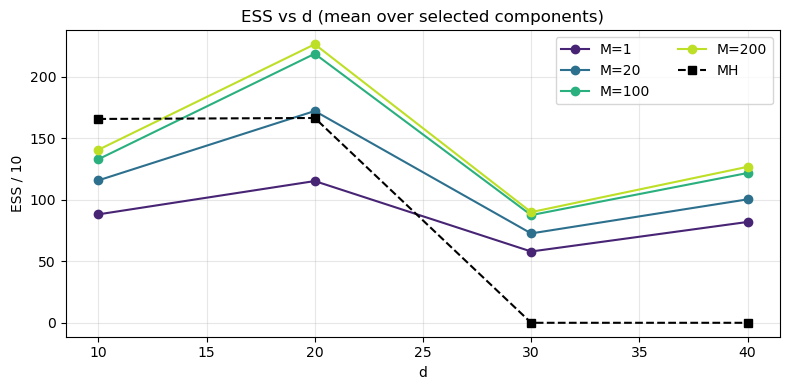

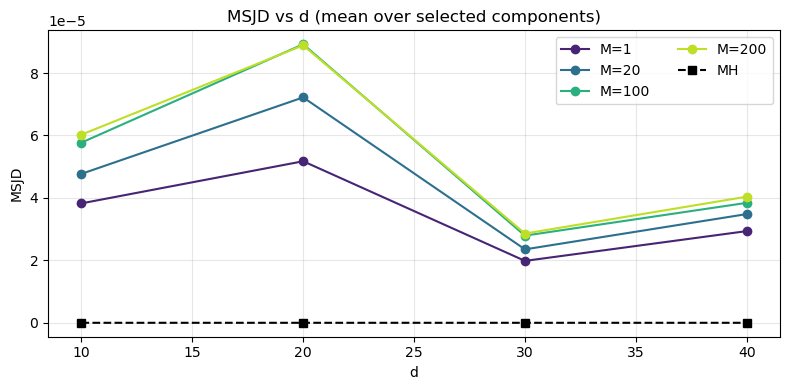

In [12]:
def plot_metric_vs_dim(metric_by_M, metric_mh, title, ylabel, filename):
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(M_list)))
    for M, color in zip(M_list, colors):
        ax.plot(d_list, metric_by_M[M], marker='o', color=color, label=f'M={M}')
    ax.plot(d_list, metric_mh, marker='s', color='black', linestyle='--', label='MH')
    ax.set_title(title)
    ax.set_xlabel('d')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend(loc='best', ncol=2)
    plt.tight_layout()
    fig.savefig(output_dir / filename, dpi=300)
    return fig

def plot_metric_ratio_vs_dim(metric_by_M, metric_mh, baseline_M, title, ylabel, filename):
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(M_list)))
    baseline = np.array(metric_by_M[baseline_M], dtype=float)

    def _ratio(values):
        values = np.array(values, dtype=float)
        with np.errstate(divide='ignore', invalid='ignore'):
            return values / baseline

    for M, color in zip(M_list, colors):
        ax.plot(d_list, _ratio(metric_by_M[M]), marker='o', color=color, label=f'M={M}')
    ax.plot(d_list, _ratio(metric_mh), marker='s', color='black', linestyle='--', label='MH')
    ax.set_title(title)
    ax.set_xlabel('d')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend(loc='best', ncol=2)
    plt.tight_layout()
    fig.savefig(output_dir / filename, dpi=300)
    return fig

def scale_metric_by_M(metric_by_M, scale):
    return {
        M: (np.array(values, dtype=float) / scale).tolist()
        for M, values in metric_by_M.items()
    }

def scale_metric_list(metric_list, scale):
    return (np.array(metric_list, dtype=float) / scale).tolist()

def _component_series(metric_by_M_components, metric_mh_components, comp_pos):
    by_M = {}
    for M in M_list:
        series = []
        for row in metric_by_M_components.get(M, []):
            if row is None or len(row) <= comp_pos:
                series.append(np.nan)
            else:
                series.append(row[comp_pos])
        by_M[M] = series
    mh_series = []
    for row in metric_mh_components:
        if row is None or len(row) <= comp_pos:
            mh_series.append(np.nan)
        else:
            mh_series.append(row[comp_pos])
    return by_M, mh_series

# Set scale for ESS plots (divide ESS values by this constant).
ess_scale_mess = 10
ess_scale_mh = 1
ess_ylabel = 'ESS' if ess_scale_mess == 1 else f'ESS / {ess_scale_mess:g}'

ess_by_M_scaled = scale_metric_by_M(metrics['ess_by_M'], ess_scale_mess)
ess_mh_scaled = scale_metric_list(metrics['ess_mh'], ess_scale_mh)

components_list = [int(v) for v in metrics.get('components', [])]
component_positions = list(range(min(2, len(components_list))))
component_labels = [f'component {components_list[pos]}' for pos in component_positions]

# Mean over selected components
plot_metric_vs_dim(
    ess_by_M_scaled, ess_mh_scaled,
    'ESS vs d (mean over selected components)', ess_ylabel, 'ess_vs_d_mean.png'
)
plot_metric_vs_dim(
    metrics['msjd_by_M'], metrics['msjd_mh'],
    'MSJD vs d (mean over selected components)', 'MSJD', 'msjd_vs_d_mean.png'
)

# plot_metric_ratio_vs_dim(
#     ess_by_M_scaled, ess_mh_scaled, 1,
#     'ESS ratio vs d (mean over selected components, vs M=1)', 'ESS / ESS(M=1)',
#     'ess_ratio_vs_d_mean.png'



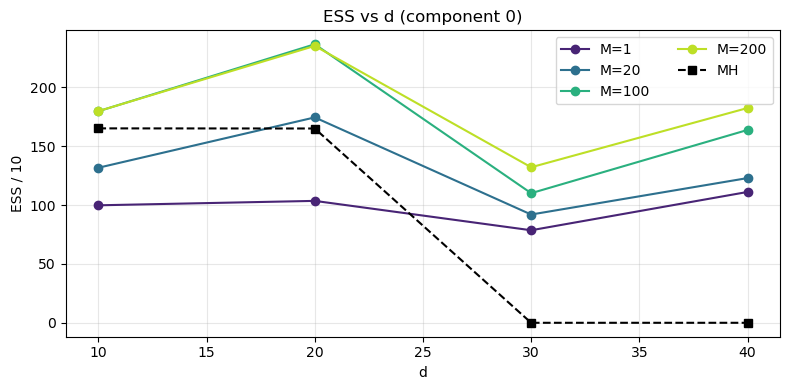

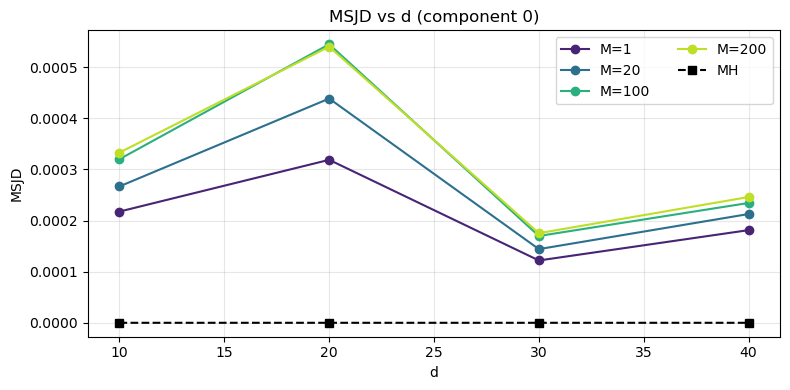

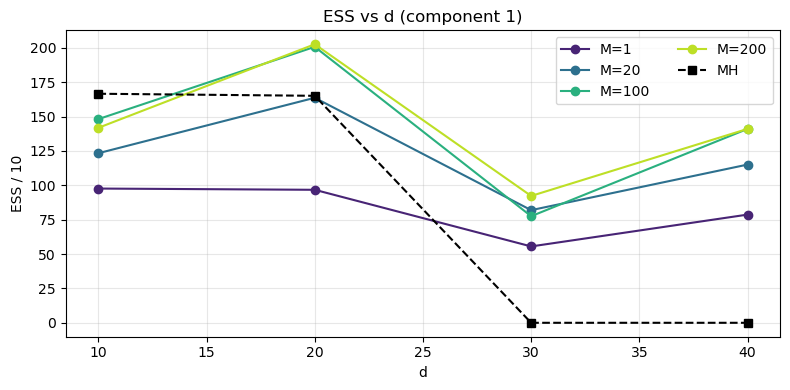

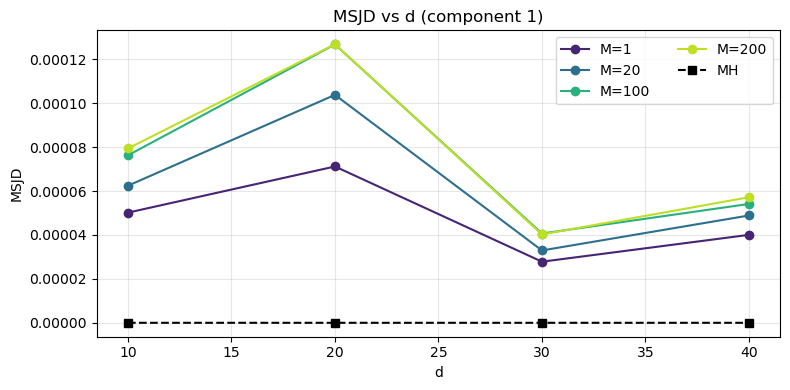

In [13]:
# Per-component ESS/MSJD plots
if len(component_positions) == 0:
    print('No components available for plotting.')
else:
    for comp_pos, comp_label in zip(component_positions, component_labels):
        ess_by_M_comp, ess_mh_comp = _component_series(
            metrics['ess_by_M_components'],
            metrics['ess_mh_components'],
            comp_pos,
        )
        ess_by_M_comp_scaled = scale_metric_by_M(ess_by_M_comp, ess_scale_mess)
        ess_mh_comp_scaled = scale_metric_list(ess_mh_comp, ess_scale_mh)
        plot_metric_vs_dim(
            ess_by_M_comp_scaled, ess_mh_comp_scaled,
            f"ESS vs d ({comp_label})", ess_ylabel, f"ess_vs_d_{comp_label.replace(' ', '_')}.png",
        )
        msjd_by_M_comp, msjd_mh_comp = _component_series(
            metrics['msjd_by_M_components'],
            metrics['msjd_mh_components'],
            comp_pos,
        )
        plot_metric_vs_dim(
            msjd_by_M_comp, msjd_mh_comp,
            f"MSJD vs d ({comp_label})", 'MSJD', f"msjd_vs_d_{comp_label.replace(' ', '_')}.png",
        )


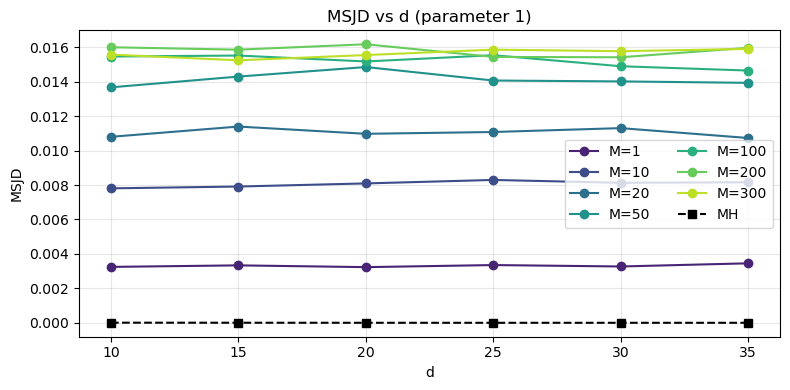

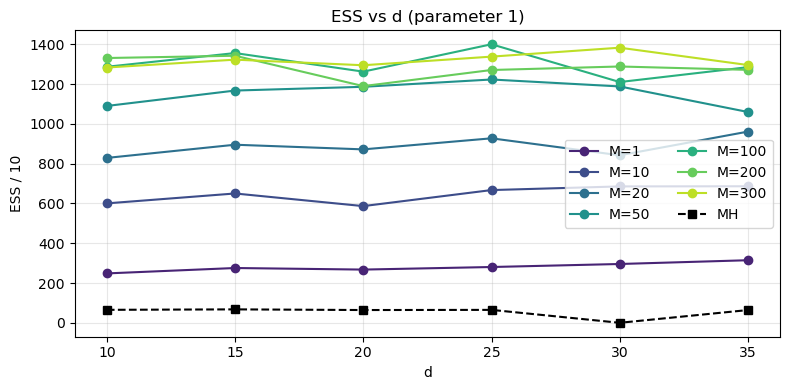

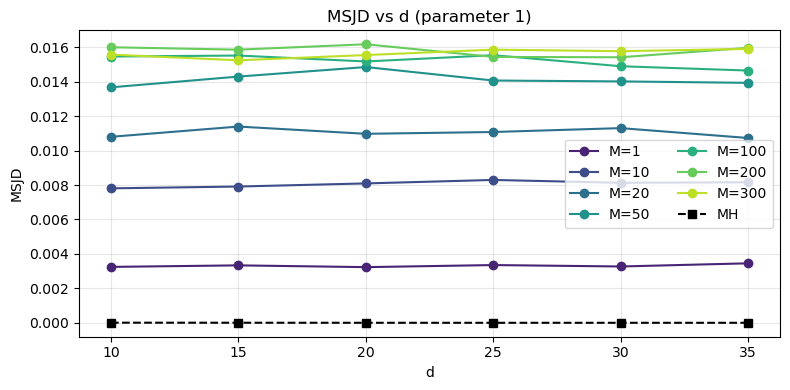

In [ ]:
# Per-component plots are generated in the previous cell.

In [45]:
# Load a single chain by selecting d and algorithm.
selected_d = 35
selected_alg = 'mh'  # 'mess' or 'mh'
selected_M = 100  # Only used when selected_alg == 'mess'

if selected_alg == 'mess':
    if selected_M is None:
        raise ValueError('selected_M must be set for MESS')
    selected_chain = load_chain(output_dir, selected_d, 'mess', M=selected_M)
    selected_label = f'MESS d={selected_d} M={selected_M}'
elif selected_alg == 'mh':
    d_idx = d_list.index(selected_d)
    mh_std = mh_proposal_stds_scaled[d_idx]
    selected_chain = load_chain(output_dir, selected_d, 'mh', proposal_std=mh_std)
    selected_label = f'MH d={selected_d} sigma2={mh_std}'
else:
    raise ValueError("selected_alg must be 'mess' or 'mh'")

if selected_chain is None or selected_chain.size == 0:
    print(f'No chain found for {selected_label}')
else:
    print(f'Loaded {selected_label} with shape {selected_chain.shape}')

# Load ESS/MSJD metrics for the selected chain (mean over params + param 0/1).
ess_mean = None
msjd_mean = None
ess_param0 = None
ess_param1 = None
msjd_param0 = None
msjd_param1 = None

d_idx = d_list.index(selected_d)
if selected_alg == 'mess':
    ess_mean = metrics['ess_by_M'][selected_M][d_idx]
    msjd_mean = metrics['msjd_by_M'][selected_M][d_idx]
    ess_param0 = metrics['ess_by_M_param0'][selected_M][d_idx]
    ess_param1 = metrics['ess_by_M_param1'][selected_M][d_idx]
    msjd_param0 = metrics['msjd_by_M_param0'][selected_M][d_idx]
    msjd_param1 = metrics['msjd_by_M_param1'][selected_M][d_idx]
else:
    ess_mean = metrics['ess_mh'][d_idx]
    msjd_mean = metrics['msjd_mh'][d_idx]
    ess_param0 = metrics['ess_mh_param0'][d_idx]
    ess_param1 = metrics['ess_mh_param1'][d_idx]
    msjd_param0 = metrics['msjd_mh_param0'][d_idx]
    msjd_param1 = metrics['msjd_mh_param1'][d_idx]

print(f'ESS mean: {ess_mean}, MSJD mean: {msjd_mean}')
print(f'ESS param0: {ess_param0}, param1: {ess_param1}')
print(f'MSJD param0: {msjd_param0}, param1: {msjd_param1}')

Loaded MH d=35 sigma2=0.0035 with shape (200001, 595)
ESS mean: 64.07970692895637, MSJD mean: 6.07017160532888e-11
ESS param0: 64.07970692895634, param1: 64.07970692895638
MSJD param0: 3.734848553084539e-11, param1: 1.5520001083164138e-10


In [47]:
compute_ess_per_param(selected_chain[:, 2], max_lag=1000)

array(100.75501018)

In [50]:
200000/(1 + 2*500/2)

399.2015968063872

In [37]:
max_lag

1500

In [30]:
np.var(selected_chain[:, 0])

np.float64(1.3695026222021406e-06)

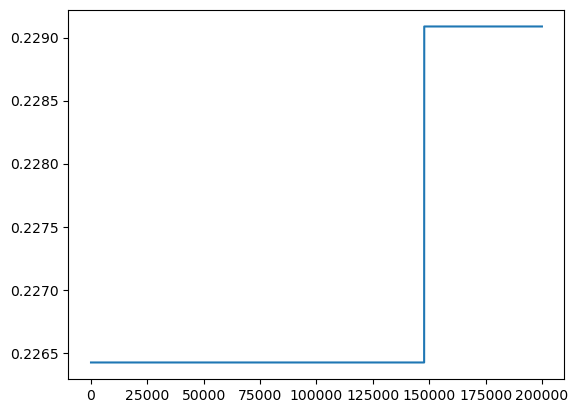

In [31]:
plt.plot(selected_chain[:, 0])

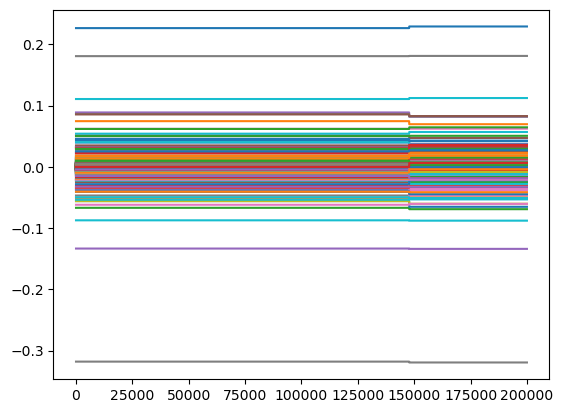

In [33]:
plt.plot(selected_chain)
plt.show()

In [ ]:
# Compare MESS uniform vs LP-angular at d=10 for param 0.
d_target = 10
M_compare = [5, 10, 20, 50]
burn_in = 10000
max_lag_local = 1500
run_missing = True  # Set False to skip running missing chains.
angular_alg = "mess_lp_ang"

def _run_mess_chain(d, M, use_lp, distance_metric=None, alg_name=None):
    alg_name = alg_name or (angular_alg if use_lp else "mess")
    existing = load_chain(output_dir, d, alg_name, M=M)
    if existing is not None and existing.size > 0:
        return existing
    if not run_missing:
        print(f"Missing chain: d={d} alg={alg_name} M={M}")
        return None
    print(f"Running MESS: d={d}, M={M}, use_lp={use_lp}, distance={distance_metric}")
    problem_cur, x0_cur, _, _ = build_problem_for_dim(d, seed=seed_data)
    rng = np.random.default_rng(seed_mcmc)
    chain = np.zeros((n_iters + 1, x0_cur.shape[0]))
    chain[0] = x0_cur.copy()
    x = x0_cur.copy()
    t0 = time.perf_counter()
    for t in range(n_iters):
        if use_lp:
            x, _, _ = mess_step(
                x,
                problem_cur,
                rng,
                M=M,
                use_lp=True,
                distance_metric=distance_metric,
                lam=0.0,
            )
        else:
            x, _, _ = mess_step(x, problem_cur, rng, M=M, use_lp=False)
        chain[t + 1] = x
    t1 = time.perf_counter()
    post = chain[::thin]
    metadata = {
        "alg": alg_name,
        "d": d,
        "M": M,
        "n_iters": n_iters,
        "burn_in": burn_in,
        "thin": thin,
        "seed_mcmc": seed_mcmc,
        "seed_data": seed_data,
        "use_lp": bool(use_lp),
        "distance_metric": distance_metric,
        "runtime_sec": t1 - t0,
    }
    save_chain(chain_path(output_dir, d, alg_name, M=M), post, metadata)
    print(f"Saved {alg_name} d={d} M={M} in {t1 - t0:.2f}s")
    return post

def _metrics_param0(chain):
    if chain is None or chain.size == 0:
        return np.nan, np.nan
    chain = chain[burn_in:] if chain.shape[0] > burn_in else chain[:0]
    if chain.shape[0] < 2:
        return np.nan, np.nan
    ess_vals = compute_ess_per_param(chain, max_lag=max_lag_local)
    msjd_vals = compute_msjd_per_param(chain)
    return float(ess_vals[0]), float(msjd_vals[0])

rows = []
for M in M_compare:
    chain_uniform = _run_mess_chain(d_target, M, use_lp=False, alg_name="mess")
    chain_angular = _run_mess_chain(d_target, M, use_lp=True, distance_metric="angular", alg_name=angular_alg)
    ess_u, msjd_u = _metrics_param0(chain_uniform)
    ess_a, msjd_a = _metrics_param0(chain_angular)
    rows.append((M, ess_u, ess_a, msjd_u, msjd_a))

def _fmt(val):
    if val is None or np.isnan(val):
        return "nan"
    return f"{val:.6g}"

lines = [
    "| M | ESS uniform | ESS LP angular | MSJD uniform | MSJD LP angular |",
    "|---|---|---|---|---|",
 ]
for M, ess_u, ess_a, msjd_u, msjd_a in rows:
    lines.append(
        f"| {M} | {_fmt(ess_u)} | {_fmt(ess_a)} | {_fmt(msjd_u)} | {_fmt(msjd_a)} |"
    )
print("\n".join(lines))

Running MESS: d=10, M=5, use_lp=False, distance=None
Saved mess d=10 M=5 in 56.40s
Running MESS: d=10, M=5, use_lp=True, distance=angular
Saved mess_lp_ang d=10 M=5 in 692.58s
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Running MESS: d=10, M=10, use_lp=True, distance=angular
Saved mess_lp_ang d=10 M=10 in 736.44s
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Running MESS: d=10, M=20, use_lp=True, distance=angular
Saved mess_lp_ang d=10 M=20 in 801.42s
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Running MESS: d=10, M=50, use_lp=True, distance=angular
Saved mess_lp_ang d=10 M=50 in 1062.72s
Estimating ESS for each parameter.
Estimating ESS for each parameter.
| M | ESS uniform | ESS LP angular | MSJD uniform | MSJD LP angular |
|---|---|---|---|---|
| 5 | 4687.14 | 3969.51 | 0.0244372 | 0.0237902 |
| 10 | 6138.51 | 6089.09 | 0.0362695 | 0.0356039 |
| 20 | 8242.56 | 8178.75 | 0.0463936 | 0.0460018 |
| 50 | 10991.2

In [53]:
# Param-0 ESS/MSJD summary table from saved chains.
def _metrics_param0(chain):
    if chain is None or chain.size == 0:
        return np.nan, np.nan
    chain = chain[burn_in:] if chain.shape[0] > burn_in else chain[:0]
    if chain.shape[0] < 2:
        return np.nan, np.nan
    ess_vals = compute_ess_per_param(chain, max_lag=max_lag_local)
    msjd_vals = compute_msjd_per_param(chain)
    return float(ess_vals[1]), float(msjd_vals[1])

summary_rows = []
for M in M_compare:
    chain_uniform = load_chain(output_dir, d_target, "mess", M=M)
    chain_angular = load_chain(output_dir, d_target, angular_alg, M=M)
    ess_u, msjd_u = _metrics_param0(chain_uniform)
    ess_a, msjd_a = _metrics_param0(chain_angular)
    summary_rows.append((M, ess_u, ess_a, msjd_u, msjd_a))

lines = [
    "| M | ESS uniform (param0) | ESS LP angular (param0) | MSJD uniform (param0) | MSJD LP angular (param0) |",
    "|---|---|---|---|---|",
 ]
for M, ess_u, ess_a, msjd_u, msjd_a in summary_rows:
    lines.append(
        f"| {M} | {_fmt(ess_u)} | {_fmt(ess_a)} | {_fmt(msjd_u)} | {_fmt(msjd_a)} |"
    )
print("\n".join(lines))

Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
| M | ESS uniform (param0) | ESS LP angular (param0) | MSJD uniform (param0) | MSJD LP angular (param0) |
|---|---|---|---|---|
| 5 | 4338.48 | 4807.23 | 0.0053833 | 0.00552119 |
| 10 | 6006.34 | 6249.06 | 0.00780931 | 0.00798693 |
| 20 | 8292.65 | 7943.59 | 0.0108032 | 0.0107891 |
| 50 | 10905.8 | 11456.9 | 0.0136773 | 0.0143594 |


In [54]:
# Param-0 ESS/MSJD summary table from saved chains.
def _metrics_param0(chain):
    if chain is None or chain.size == 0:
        return np.nan, np.nan
    chain = chain[burn_in:] if chain.shape[0] > burn_in else chain[:0]
    if chain.shape[0] < 2:
        return np.nan, np.nan
    ess_vals = compute_ess_per_param(chain, max_lag=max_lag_local)
    msjd_vals = compute_msjd_per_param(chain)
    return float(ess_vals[2]), float(msjd_vals[2])

summary_rows = []
for M in M_compare:
    chain_uniform = load_chain(output_dir, d_target, "mess", M=M)
    chain_angular = load_chain(output_dir, d_target, angular_alg, M=M)
    ess_u, msjd_u = _metrics_param0(chain_uniform)
    ess_a, msjd_a = _metrics_param0(chain_angular)
    summary_rows.append((M, ess_u, ess_a, msjd_u, msjd_a))

lines = [
    "| M | ESS uniform (param0) | ESS LP angular (param0) | MSJD uniform (param0) | MSJD LP angular (param0) |",
    "|---|---|---|---|---|",
 ]
for M, ess_u, ess_a, msjd_u, msjd_a in summary_rows:
    lines.append(
        f"| {M} | {_fmt(ess_u)} | {_fmt(ess_a)} | {_fmt(msjd_u)} | {_fmt(msjd_a)} |"
    )
print("\n".join(lines))

Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.
| M | ESS uniform (param0) | ESS LP angular (param0) | MSJD uniform (param0) | MSJD LP angular (param0) |
|---|---|---|---|---|
| 5 | 4633.96 | 3990.35 | 0.00211131 | 0.00213407 |
| 10 | 5967.14 | 6655.67 | 0.00298614 | 0.0030885 |
| 20 | 8346.07 | 8869.74 | 0.00401602 | 0.0043283 |
| 50 | 12033.7 | 10901.8 | 0.00537791 | 0.00544877 |
